# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import math
from sklearn.metrics import mutual_info_score

DATA_PATH = Path("raw/Telco-Customer-Churn.csv")
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["customerID"])

# Primer vistazo

In [4]:
print(df.shape)
print(df.columns)

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [2]:
for column in df.columns:
    print('Column: {} - Unique Values: {}'.format(column, df[column].unique()))

Column: gender - Unique Values: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Column: SeniorCitizen - Unique Values: [0 1]
Column: Partner - Unique Values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Column: Dependents - Unique Values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Column: tenure - Unique Values: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
Column: PhoneService - Unique Values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Column: MultipleLines - Unique Values: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
Column: InternetService - Unique Values: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
Column: OnlineSecurity - Unique Values: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Column: OnlineBackup - Uniq

In [19]:
df["TotalCharges"].head(20)


0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: str

In [9]:
df["TotalCharges_test"] = df["TotalCharges"]
df["TotalCharges_test"] = pd.to_numeric(
    df["TotalCharges_test"],
    errors="coerce"
)

In [21]:
df["TotalCharges_test"].isna().sum()

np.int64(11)

In [12]:
df[df["TotalCharges_test"].isna()]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_test
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No,NaN
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No,NaN
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,,No,NaN
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No,NaN
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No,NaN
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No,NaN
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No,NaN
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No,NaN
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No,NaN
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,Yes,No,Two year,No,Mailed check,73.35,,No,NaN


In [23]:
df[df["TotalCharges_test"].isna()][["TotalCharges", "TotalCharges_test"]]

,TotalCharges,TotalCharges_test
488,,NaN
753,,NaN
936,,NaN
1082,,NaN
1340,,NaN
3331,,NaN
3826,,NaN
4380,,NaN
5218,,NaN
6670,,NaN


In [9]:
df[df["TotalCharges_test"].isna()]
df = df.drop(columns=["TotalCharges_test"])


In [7]:
print(f"Categorías: {df['SeniorCitizen'].nunique()}")
print(df['SeniorCitizen'].value_counts())

Categorías: 2
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


# Manejo de NaNs en TotalCharges

In [2]:
#Paso total charges a int, limpio los NaNs
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

#Hay muchos casos donde el totalCharge es NaN porque el tenure es 0 pero hay info en MonthlyCharge
mask = (
    df["TotalCharges"].isna() &
    (df["tenure"] == 0)
)

#En ese caso lo lleno con el valor de monthlyCharge
df.loc[mask, "TotalCharges"] = df.loc[mask, "MonthlyCharges"]

df = df.dropna(subset=["TotalCharges"])

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# Distribuciones

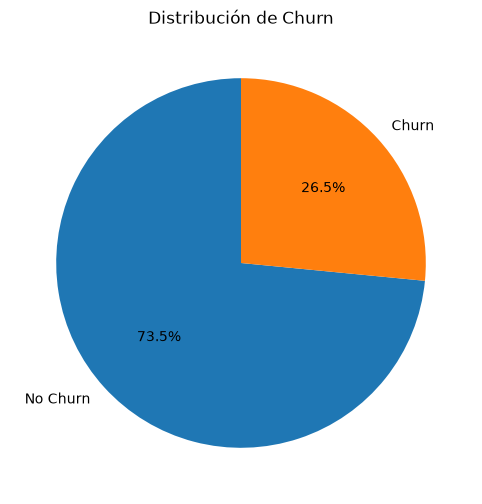

In [9]:
churn_pct = df["Churn"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 6))
plt.pie(
    churn_pct,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribución de Churn")
plt.show()

### Hay un claro desbalance desbalance, el 73% de los clientes no abandona y el 26% si lo hace. Obviamente son numeros que tienen sentido, uno no espera que un servicio tenga una tasa de desercion del 50%.

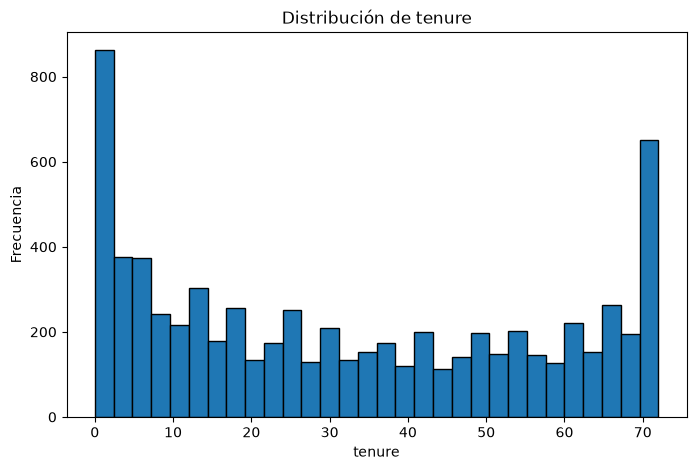

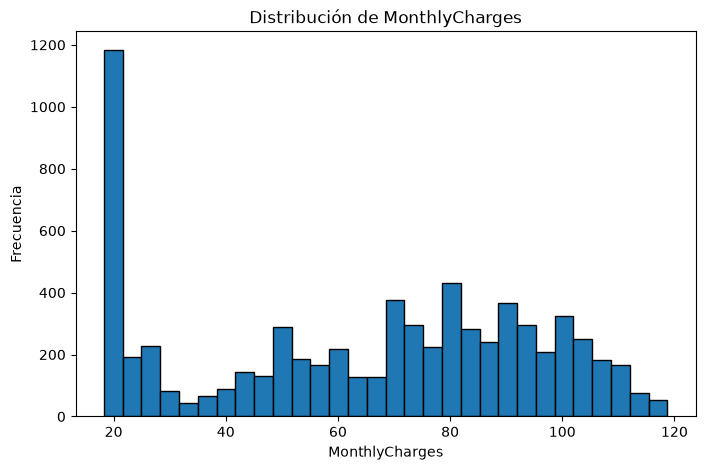

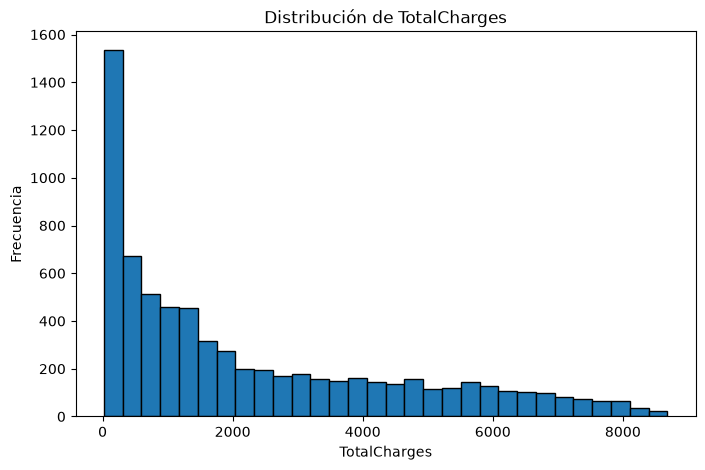

In [11]:
import matplotlib.pyplot as plt

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col], bins=30, edgecolor="black")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

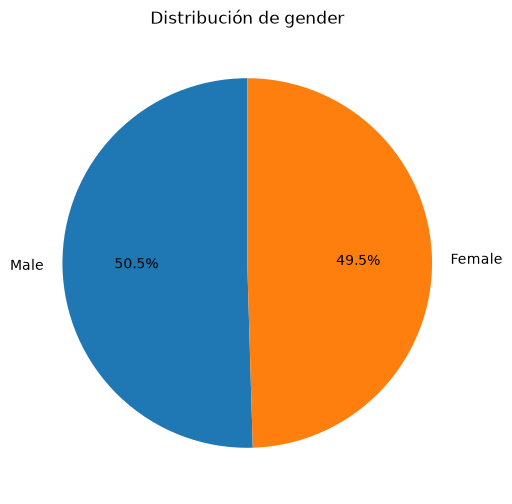

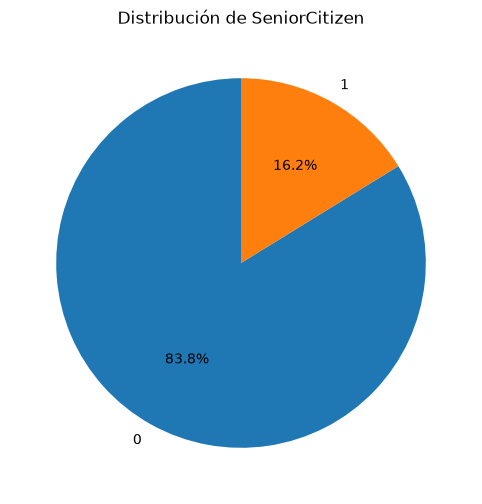

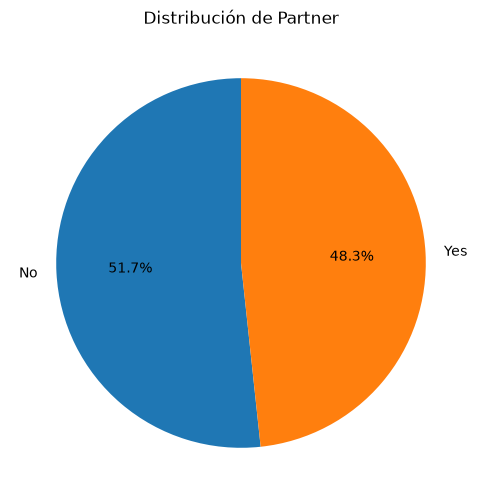

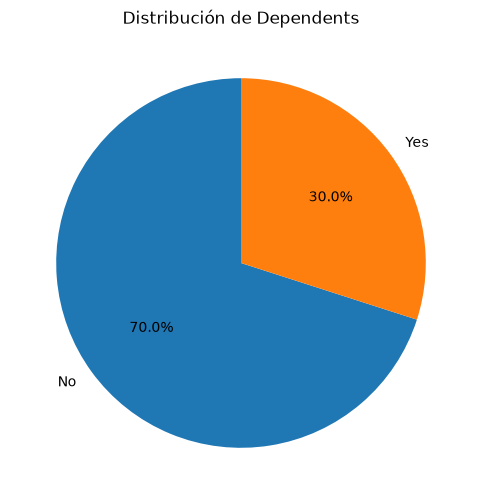

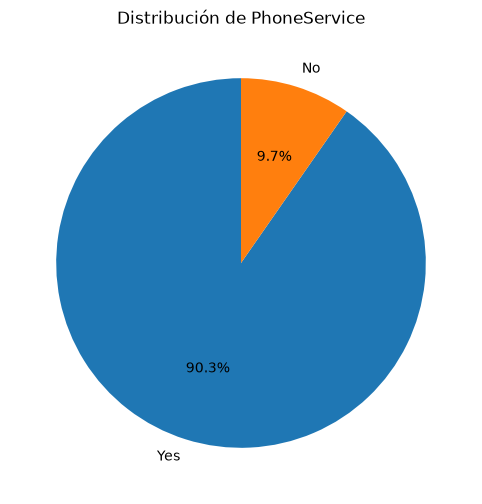

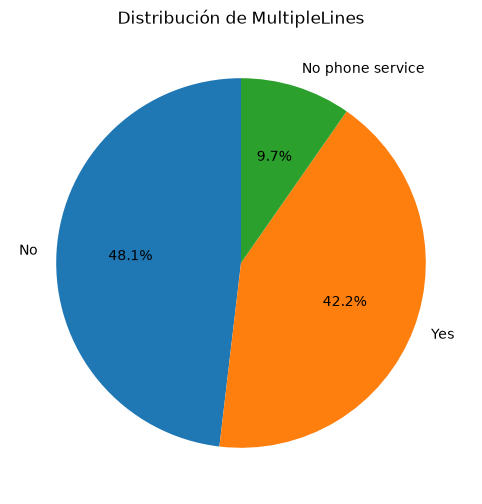

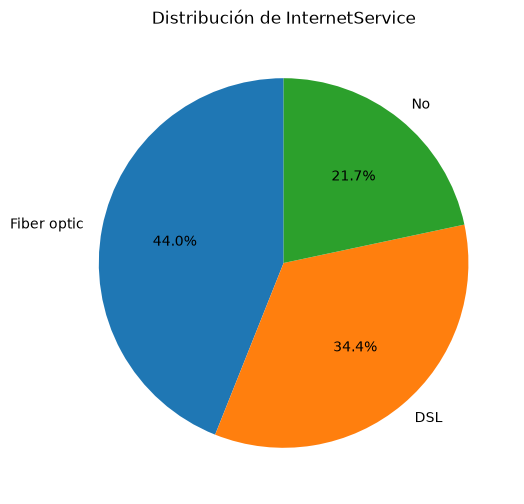

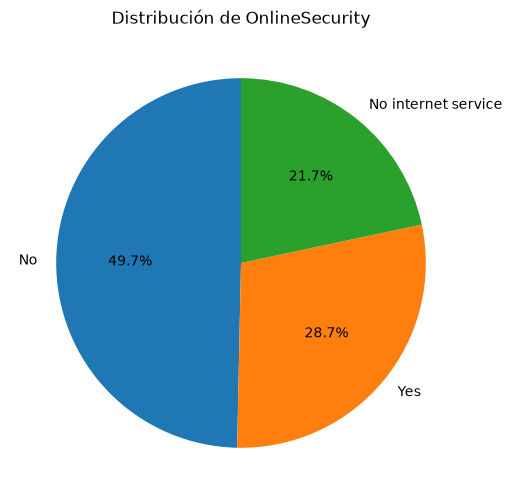

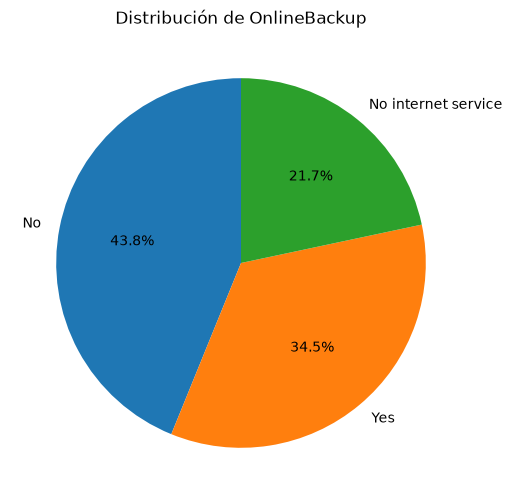

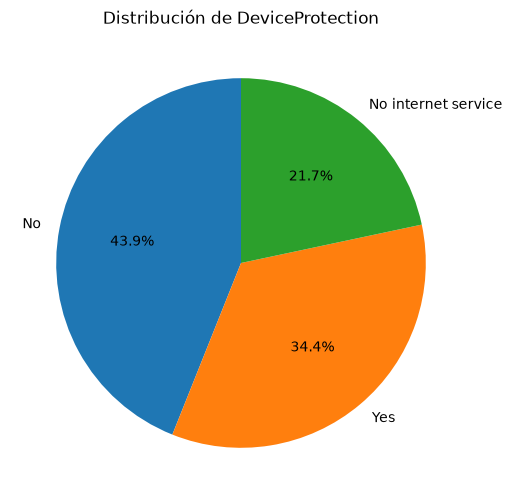

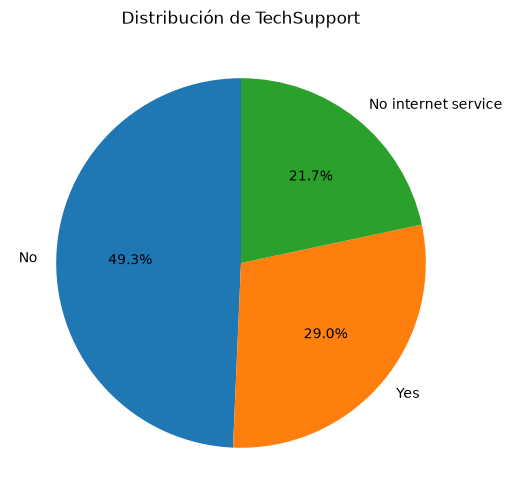

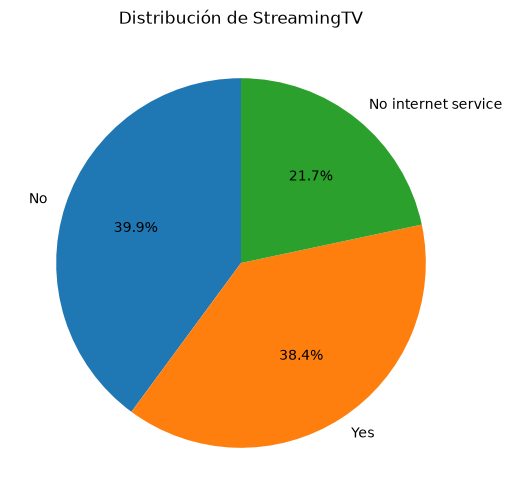

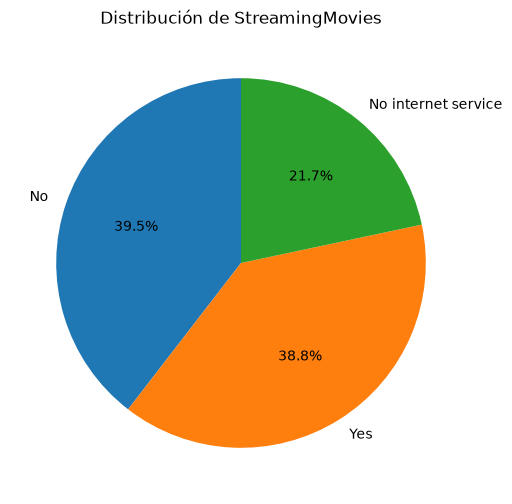

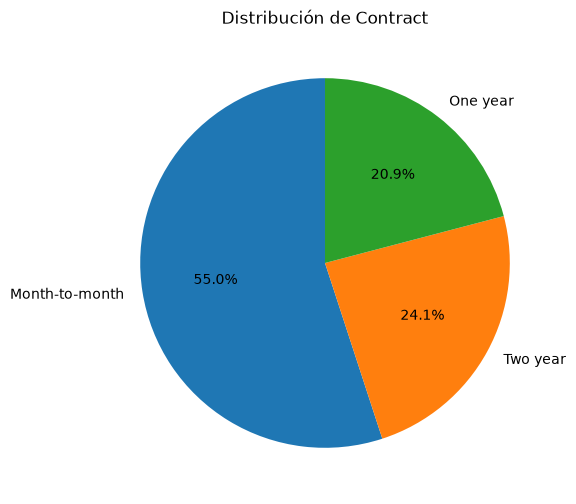

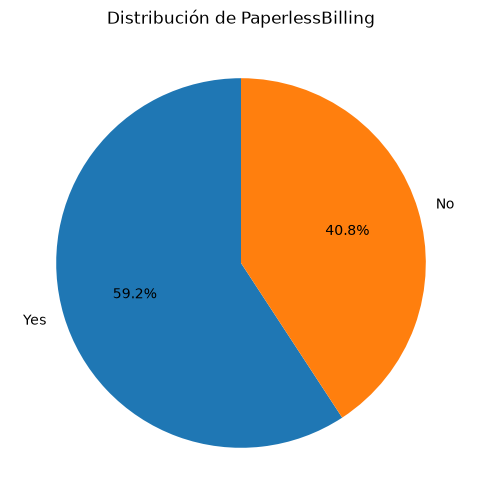

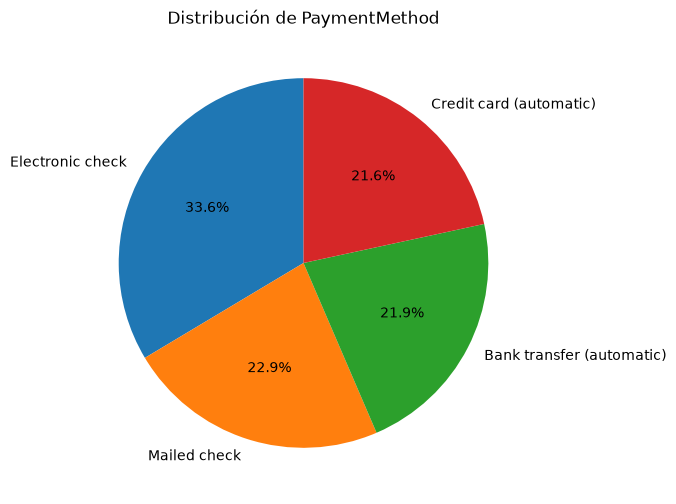

In [14]:
cat_cols = [
    col for col in df.columns
    if col not in num_cols + ["Churn"]
]

for col in cat_cols:
    col_pct = df[col].value_counts(normalize=True) * 100
    plt.figure(figsize=(6, 6))
    plt.pie(
        col_pct,
        labels=col_pct.index,
        autopct="%1.1f%%",
        startangle=90
    )
    plt.title(f"Distribución de {col}")
    plt.show()

In [10]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[num_cols].corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


# Relación entre churn y variables categoricas

In [33]:
def percentage_stacked_plot(columns_to_plot, super_title, target_col="Churn"):
    n_cols = 2
    n_rows = math.ceil(len(columns_to_plot) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(13, 4.8 * n_rows)
    )

    axes = np.atleast_1d(axes).flatten()
    colors = ["#D9D9D9", "#4C78A8"]

    # Dynamically find the two classes in the target column (e.g., 0/1, "No"/"Yes")
    target_classes = sorted(df[target_col].dropna().unique())
    if len(target_classes) != 2:
        raise ValueError(f"The target column '{target_col}' must have exactly 2 unique values.")
    
    class_0, class_1 = target_classes[0], target_classes[1]

    for ax, column in zip(axes, columns_to_plot):
        # Calculate proportions
        prop = (
            pd.crosstab(
                df[column],
                df[target_col],
                normalize="index"
            )
            .mul(100)
            .reindex(columns=[class_0, class_1], fill_value=0) # Uses dynamic classes
        )

        labels = prop.index.astype(str).tolist()

        # Safely handle empty labels array before checking length
        max_label_length = max([len(label) for label in labels]) if labels else 0
        horizontal = max_label_length > 15

        no_churn = prop[class_0].values
        churn = prop[class_1].values

        if horizontal:
            y = np.arange(len(labels))

            ax.barh(y, no_churn, height=0.65, color=colors[0])
            ax.barh(y, churn, height=0.65, left=no_churn, color=colors[1])

            ax.set_yticks(y)
            ax.set_yticklabels(labels)
            ax.set_xlim(0, 100)
            ax.set_xticks([0, 25, 50, 75, 100])
            ax.set_xlabel("Porcentaje (%)")

            for i, (nc, c) in enumerate(zip(no_churn, churn)):
                if nc >= 5:
                    ax.text(nc / 2, i, f"{nc:.0f}%", ha="center", va="center", 
                            fontsize=9, fontweight="bold", color="#333333")
                if c >= 5:
                    ax.text(nc + c / 2, i, f"{c:.0f}%", ha="center", va="center", 
                            fontsize=9, fontweight="bold", color="white")

        else:
            x = np.arange(len(labels))

            ax.bar(x, no_churn, width=0.65, color=colors[0])
            ax.bar(x, churn, width=0.65, bottom=no_churn, color=colors[1])

            ax.set_xticks(x)
            ax.set_xticklabels(labels)
            ax.set_ylim(0, 100)
            ax.set_yticks([0, 25, 50, 75, 100])
            ax.set_ylabel("Porcentaje (%)")

            for i, (nc, c) in enumerate(zip(no_churn, churn)):
                if nc >= 5:
                    ax.text(i, nc / 2, f"{nc:.0f}%", ha="center", va="center", 
                            fontsize=9, fontweight="bold", color="#333333")
                if c >= 5:
                    ax.text(i, nc + c / 2, f"{c:.0f}%", ha="center", va="center", 
                            fontsize=9, fontweight="bold", color="white")

        ax.set_title(column, fontsize=14, fontweight="bold", loc="center", pad=10)
        ax.grid(axis="x" if horizontal else "y", linestyle="--", alpha=0.25)
        ax.set_axisbelow(True)

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.tick_params(length=0)

    # Remove empty subplots
    for ax in axes[len(columns_to_plot):]:
        ax.remove()

    # General Legend
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors[0]),
        plt.Rectangle((0, 0), 1, 1, color=colors[1])
    ]

    fig.legend(
        handles,
        [f"No {target_col}", target_col], # Dynamic labels based on the target column
        loc="upper center",
        bbox_to_anchor=(0.5, 0.94),
        ncol=2,
        frameon=False
    )

    fig.suptitle(super_title, fontsize=20, fontweight="bold", y=0.99)
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

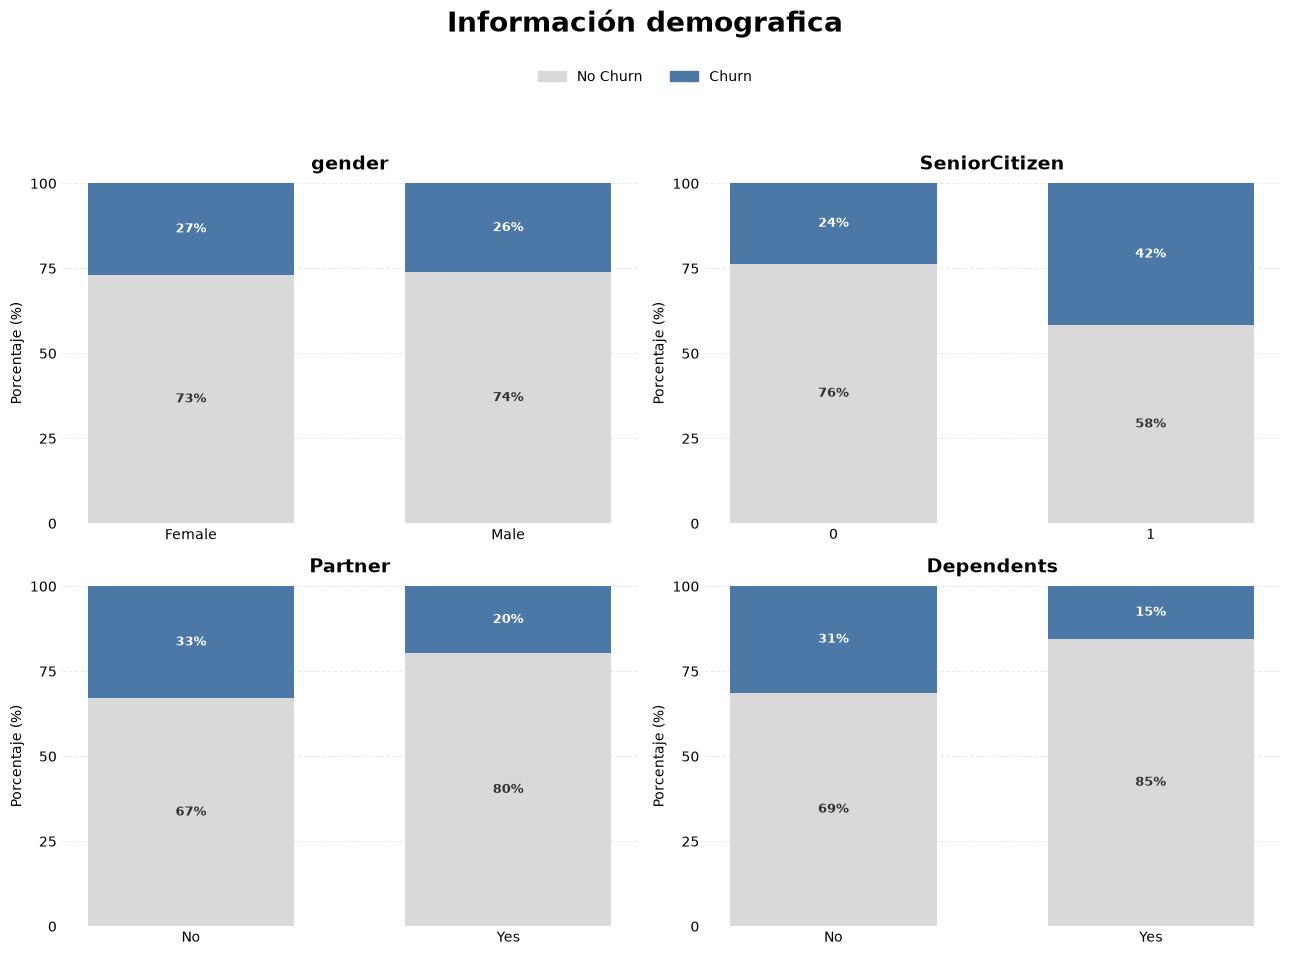

In [34]:
demographic_columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

percentage_stacked_plot(demographic_columns, 'Información demografica')

### La tasa de desercion entre hombres y mujeres es casi igual, lo que quiere decir que no hay mucha relación entre el genero y la tasa de abandono.
### Por otro lado el resto de las variables si tienen relación con la tasa de abandono, siendo seniorCitizen la más notable. La tasa de deserción de un senior citizen es del 42% a comparación del 24% que tiene un ciudadano común

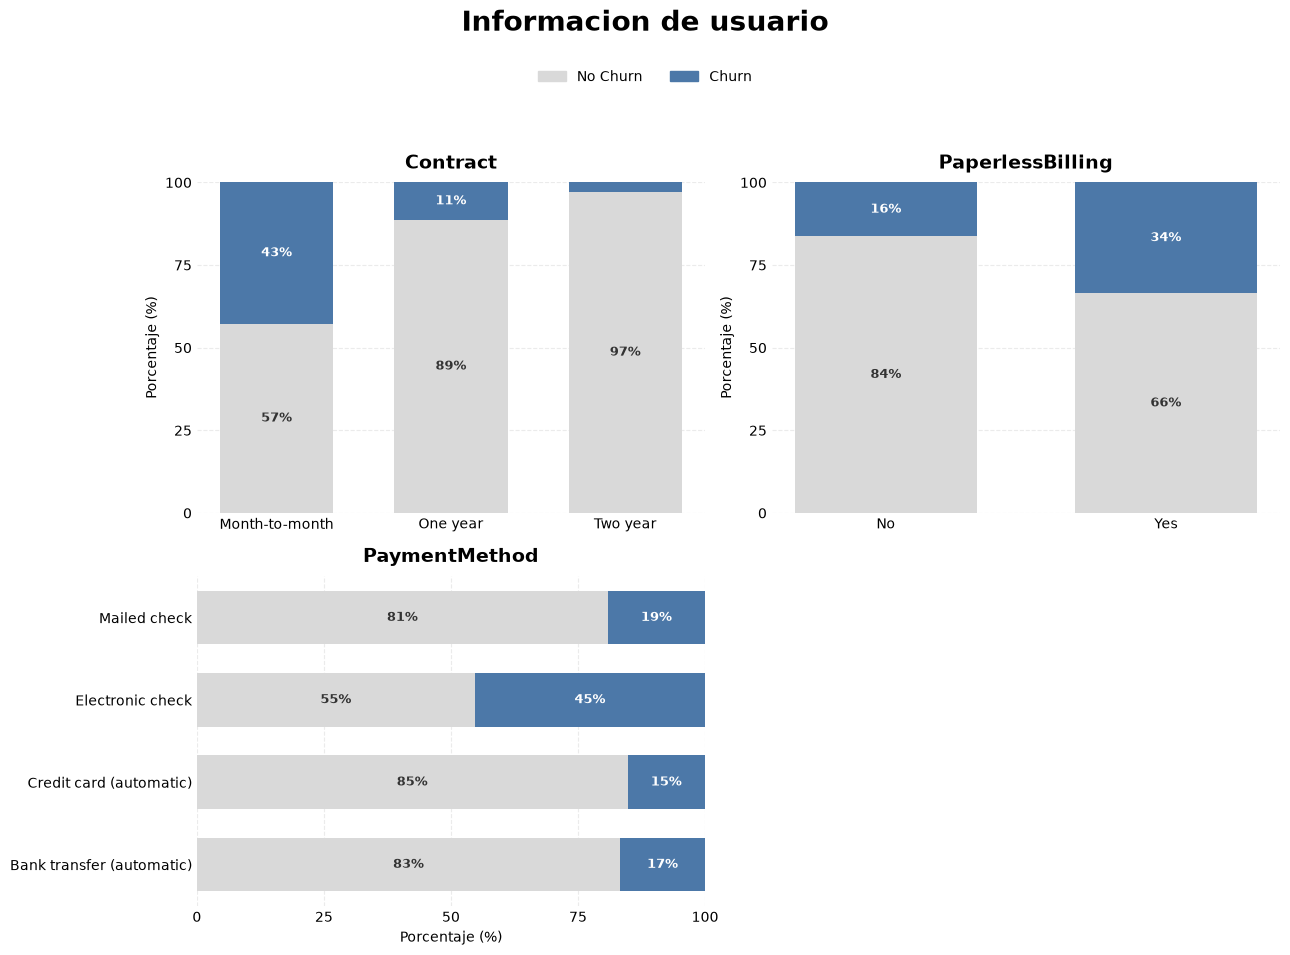

In [35]:
account_columns = ['Contract', 'PaperlessBilling', 'PaymentMethod']

percentage_stacked_plot(account_columns, 'Informacion de usuario')

### En este caso el contrato está muy relacionado a la tasa de abandono, mientras más corto es el contrato más alta es la chance de abandonar el servicio.
### Papperles billing y paymentMethod tambien estan muy relacionados con la tasa de abandono. Dentro del metodo de pago la categoria Electronic Check tiene una tasa altisima de deserción.

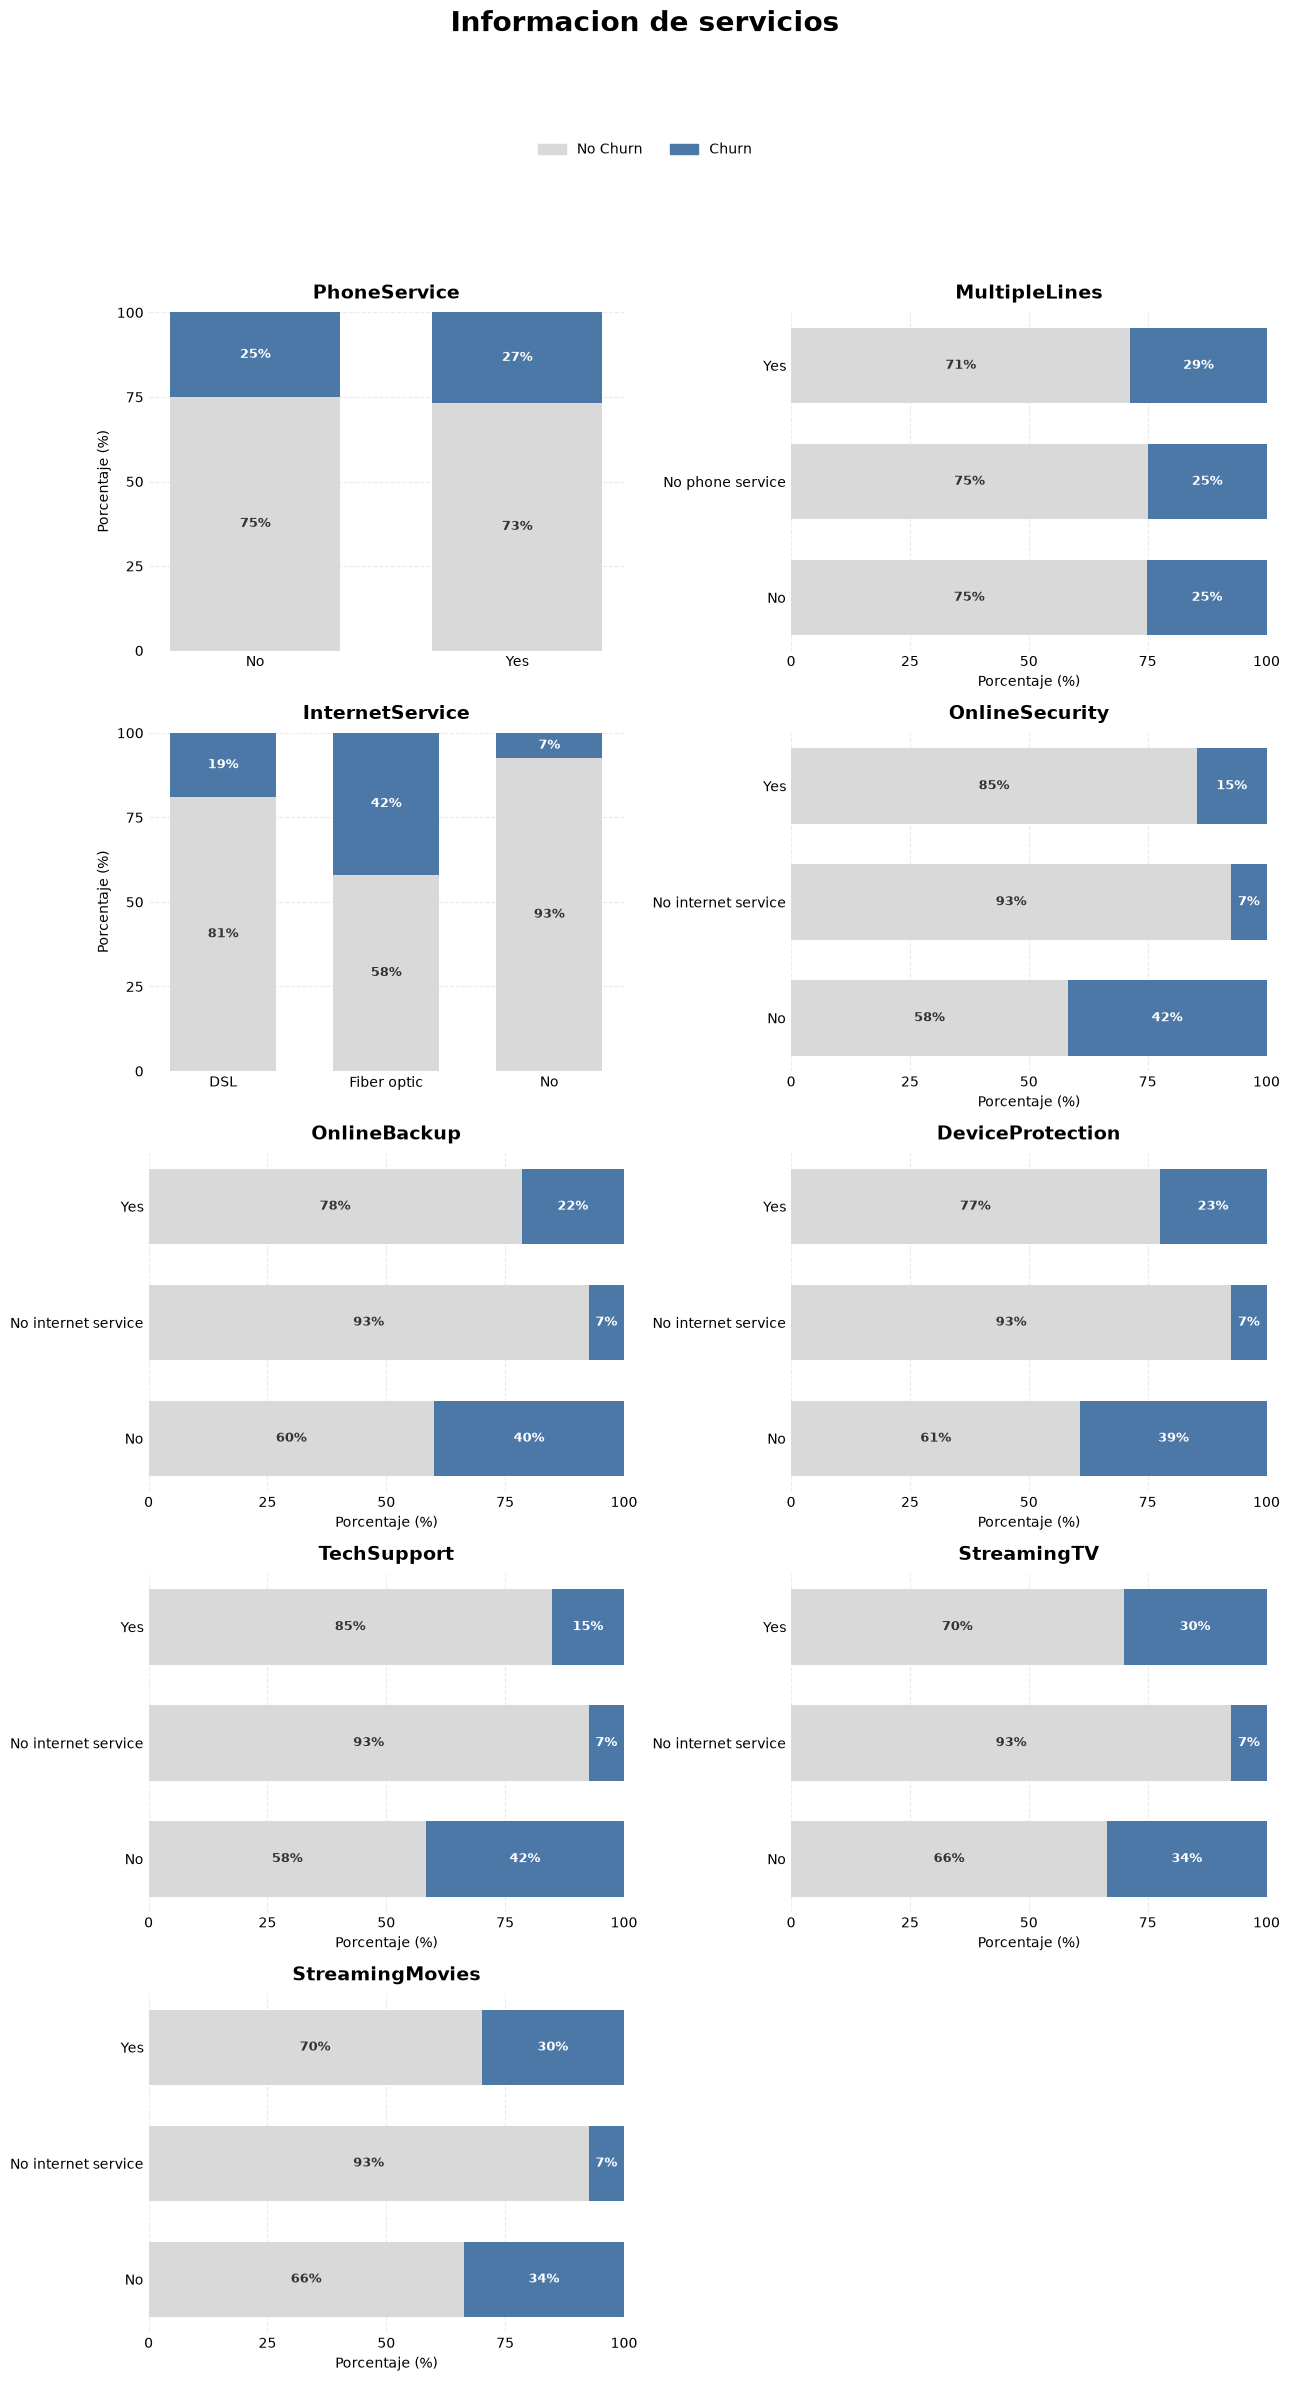

In [36]:

services_columns = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                   'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

percentage_stacked_plot(services_columns, 'Informacion de servicios')


### Acá podemos ver que el servicio de telefono y la cantidad de lineas no tienen mucha relación con la tasa de abandono. Posteriormente se ve que algunas features relacionada al servicio de internet tienen una fuerte relación con la tasa de abandono. Por ejemplo no tener seguridad online, tech support, backup online y device protecion aumentan la probabilidad de tasa de abandono. Entre los tipos de internet fibra optica es el mas relacionado a la desercion del servicio.

In [ ]:
def compute_mutual_information(categorical_serie):
    return mutual_info_score(categorical_serie, df.Churn)

categorical_variables = df.select_dtypes(include=object).drop('Churn', axis=1)

feature_importance = categorical_variables.apply(compute_mutual_information).sort_values(ascending=False)

print(feature_importance)

Contract            0.098182
OnlineSecurity      0.064528
TechSupport         0.062873
InternetService     0.055394
OnlineBackup        0.046659
PaymentMethod       0.044423
DeviceProtection    0.043784
StreamingMovies     0.031918
StreamingTV         0.031803
PaperlessBilling    0.019119
Dependents          0.014270
Partner             0.011383
MultipleLines       0.000798
PhoneService        0.000069
gender              0.000037
dtype: float64


/tmp/ipykernel_4168/2083356941.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_variables = df.select_dtypes(include=object).drop('Churn', axis=1)


Estos números confirman lo dicho sobre PhoneService, MultipleLines y gender

# Análisis sobre población que abandona el servicio 

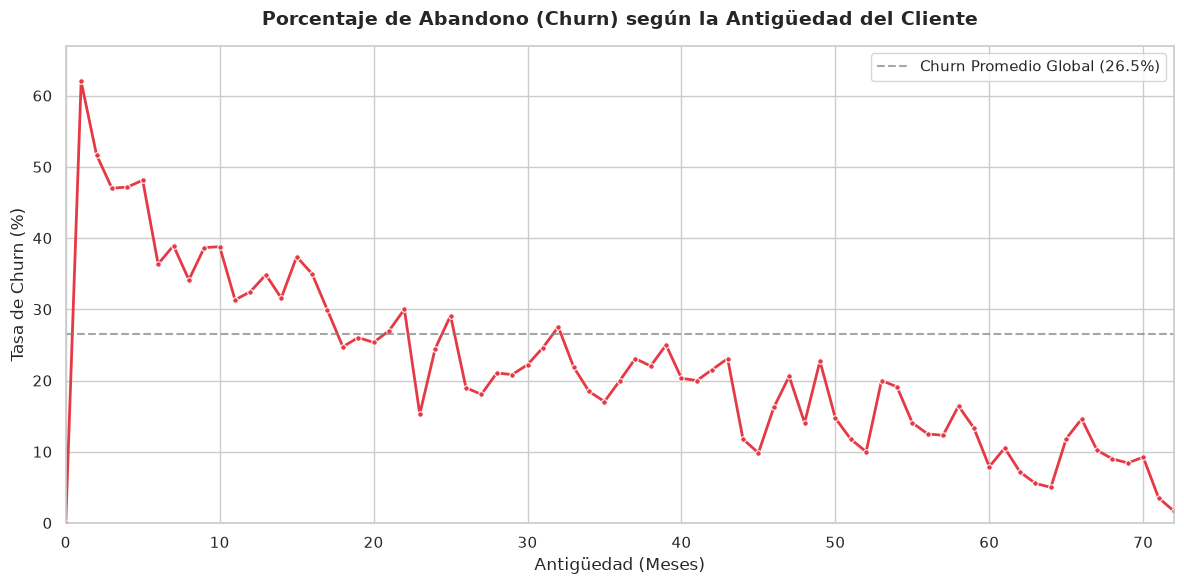

In [5]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})


churn_rate = df.groupby("tenure")["Churn"].mean() * 100

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    x=churn_rate.index, 
    y=churn_rate.values, 
    color="#e63946", 
    linewidth=2,
    marker="o",        
    markersize=4
)

plt.title("Porcentaje de Abandono (Churn) según la Antigüedad del Cliente", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Antigüedad (Meses)", fontsize=12)
plt.ylabel("Tasa de Churn (%)", fontsize=12)

plt.xlim(0, 72)
plt.ylim(0, churn_rate.max() + 5)

global_churn = df["Churn"].mean() * 100
plt.axhline(global_churn, color="gray", linestyle="--", alpha=0.7, label=f"Churn Promedio Global ({global_churn:.1f}%)")

plt.legend()
plt.tight_layout()
plt.show()

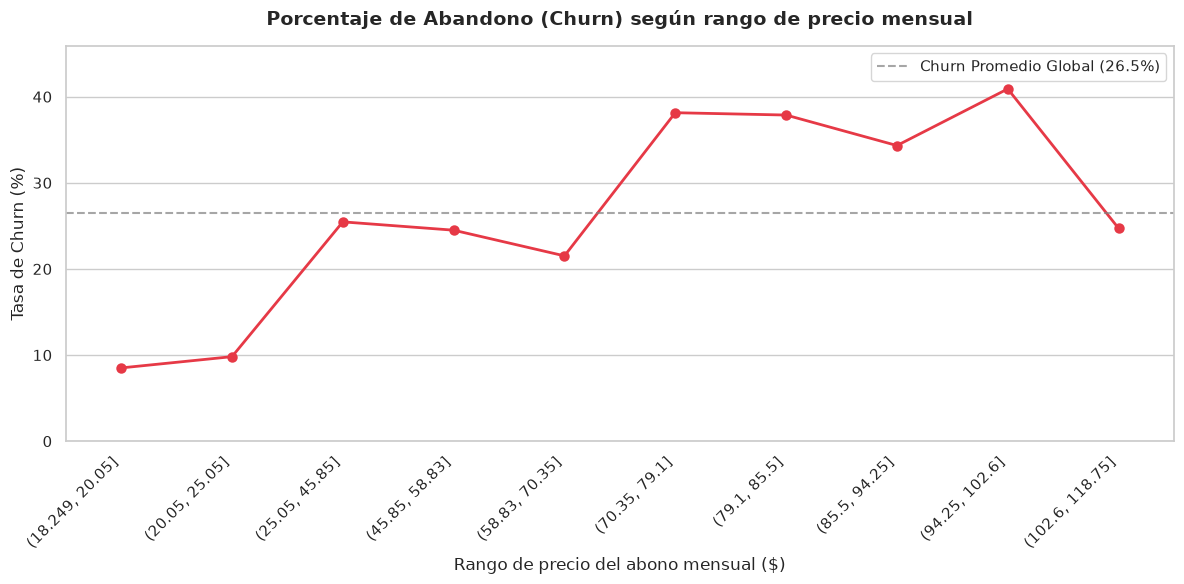

In [34]:
# agrupo los precios para que el grafico tenga sentido
df["Price_Bin"] = pd.qcut(df["MonthlyCharges"], q=10)
churn_rate = df.groupby("Price_Bin")["Churn"].mean() * 100

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.pointplot(
    x=churn_rate.index.astype(str), 
    y=churn_rate.values, 
    color="#e63946", 
    linewidth=2,
    marker="o",        
    markersize=6
)

plt.title("Porcentaje de Abandono (Churn) según rango de precio mensual", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Rango de precio del abono mensual ($)", fontsize=12)
plt.ylabel("Tasa de Churn (%)", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.ylim(0, churn_rate.max() + 5)

global_churn = df["Churn"].mean() * 100
plt.axhline(global_churn, color="gray", linestyle="--", alpha=0.7, label=f"Churn Promedio Global ({global_churn:.1f}%)")

plt.legend()
plt.tight_layout()
plt.show()
df = df.drop(columns =["Price_Bin"])

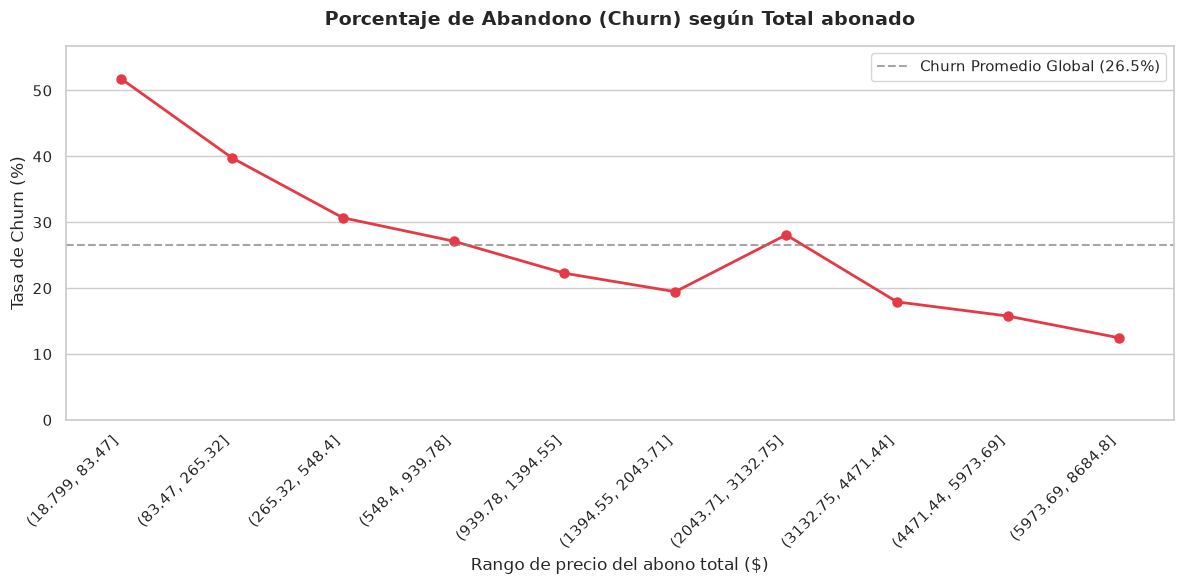

In [35]:

df["Price_Bin"] = pd.qcut(df["TotalCharges"], q=10)

churn_rate = df.groupby("Price_Bin")["Churn"].mean() * 100

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.pointplot(
    x=churn_rate.index.astype(str), 
    y=churn_rate.values, 
    color="#e63946", 
    linewidth=2,
    marker="o",        
    markersize=6
)

plt.title("Porcentaje de Abandono (Churn) según Total abonado", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Rango de precio del abono total ($)", fontsize=12)
plt.ylabel("Tasa de Churn (%)", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.ylim(0, churn_rate.max() + 5)

global_churn = df["Churn"].mean() * 100
plt.axhline(global_churn, color="gray", linestyle="--", alpha=0.7, label=f"Churn Promedio Global ({global_churn:.1f}%)")

plt.legend()
plt.tight_layout()
plt.show()
df = df.drop(columns =["Price_Bin"])

In [13]:
df["meanMonthlyCharge"] = np.where(
    df["tenure"] == 0, #condicion
    df["MonthlyCharges"], #if true
    round(df["TotalCharges"] / df["tenure"],3) #else
)


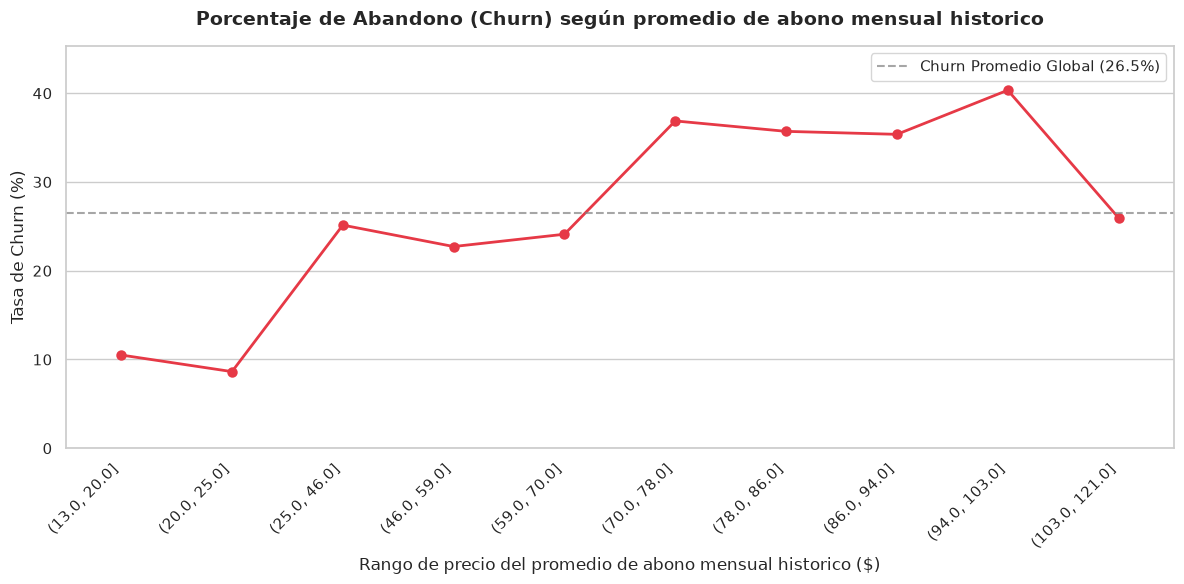

In [32]:

df["Price_Bin"] = pd.qcut(df["meanMonthlyCharge"], q=10, precision=0)

churn_rate = df.groupby("Price_Bin")["Churn"].mean() * 100

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.pointplot(
    x=churn_rate.index.astype(str), 
    y=churn_rate.values, 
    color="#e63946", 
    linewidth=2,
    marker="o",        
    markersize=6
)

plt.title("Porcentaje de Abandono (Churn) según promedio de abono mensual historico", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Rango de precio del promedio de abono mensual historico ($)", fontsize=12)
plt.ylabel("Tasa de Churn (%)", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.ylim(0, churn_rate.max() + 5)

global_churn = df["Churn"].mean() * 100
plt.axhline(global_churn, color="gray", linestyle="--", alpha=0.7, label=f"Churn Promedio Global ({global_churn:.1f}%)")

plt.legend()
plt.tight_layout()
plt.show()

df = df.drop(columns=["Price_Bin"])

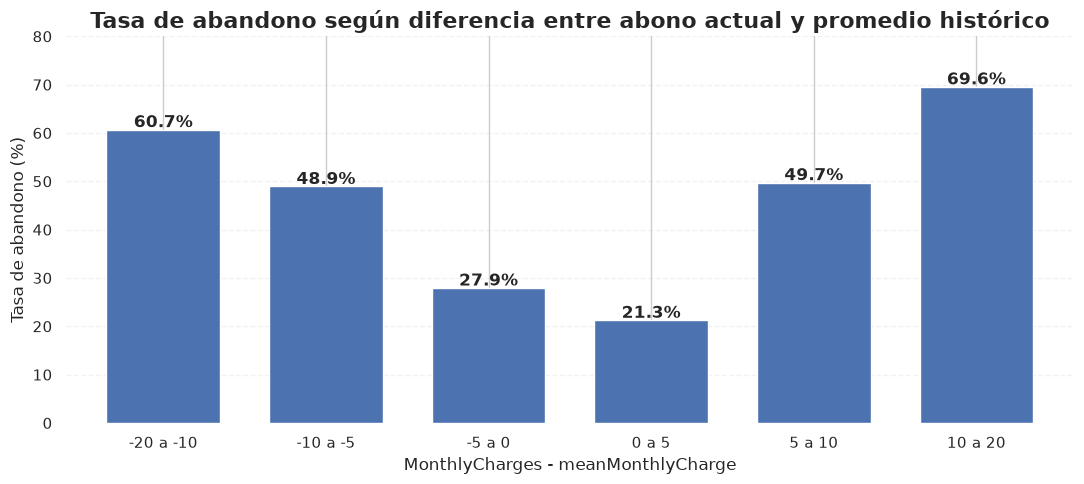

In [33]:
df["charge_difference"] = (
    df["MonthlyCharges"] - df["meanMonthlyCharge"]
)

bins = [-np.inf, -20, -10, -5, 0, 5, 10, 20, np.inf]

labels = [
    "< -20",
    "-20 a -10",
    "-10 a -5",
    "-5 a 0",
    "0 a 5",
    "5 a 10",
    "10 a 20",
    "> 20"
]

df["charge_diff_group"] = pd.cut(
    df["charge_difference"],
    bins=bins,
    labels=labels
)

churn_rate = (
    df.groupby("charge_diff_group", observed=False)["Churn"]
    .mean()
    .mul(100)
    .dropna()
)

plt.figure(figsize=(11, 5))

ax = churn_rate.plot(
    kind="bar",
    width=0.7
)

ax.set_title(
    "Tasa de abandono según diferencia entre abono actual y promedio histórico",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("MonthlyCharges - meanMonthlyCharge")
ax.set_ylabel("Tasa de abandono (%)")

ax.set_ylim(0, churn_rate.max() * 1.15)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", rotation=0)

for i, value in enumerate(churn_rate):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

df = df.drop(columns=["charge_diff_group"])

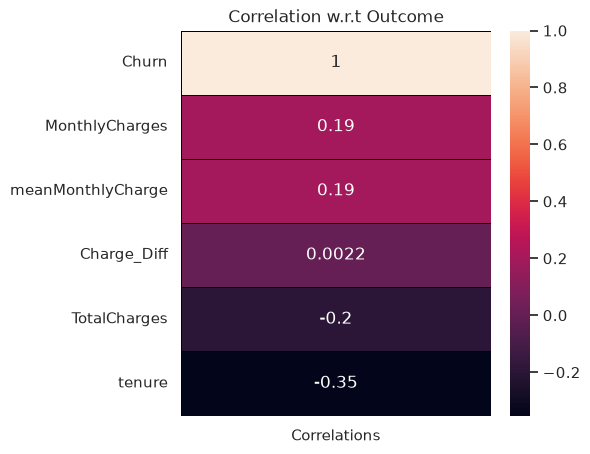

In [51]:
df_num = df[['Churn', 'MonthlyCharges', 'meanMonthlyCharge', 'Charge_Diff', 'tenure','TotalCharges']]

corr = df_num.corrwith(df_num['Churn']).sort_values(ascending = False).to_frame()
corr.columns = ['Correlations']
plt.subplots(figsize = (5,5))
sns.heatmap(corr,annot = True,linewidths = 0.4,linecolor = 'black');
plt.title('Correlation w.r.t Outcome');


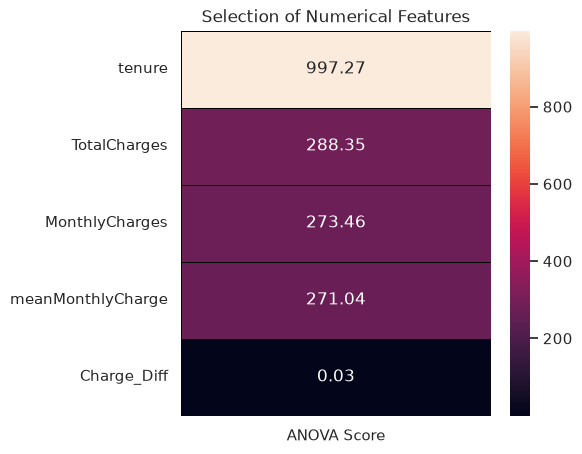

In [52]:
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest

features = df[['MonthlyCharges', 'meanMonthlyCharge', 'Charge_Diff', 'tenure','TotalCharges']]
target = df['Churn']

best_features = SelectKBest(score_func = f_classif,k = 'all')
fit = best_features.fit(features,target)

featureScores = pd.DataFrame(data = fit.scores_,index = list(features.columns),columns = ['ANOVA Score']) 

plt.subplots(figsize = (5,5))
sns.heatmap(featureScores.sort_values(ascending = False,by = 'ANOVA Score'),annot = True,linewidths = 0.4,linecolor = 'black',fmt = '.2f');
plt.title('Selection of Numerical Features');


# Análisis sobre usuarios que abandonaron 

In [29]:
churned = df[df['Churn'] == 1]

/tmp/ipykernel_3881/2987935311.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


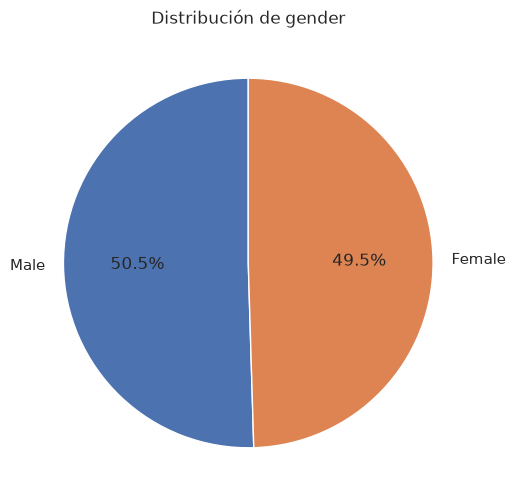

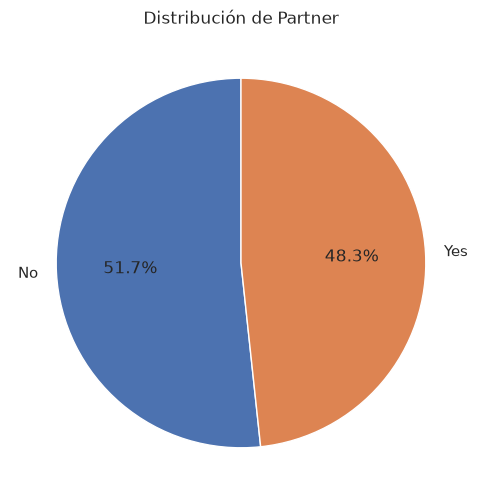

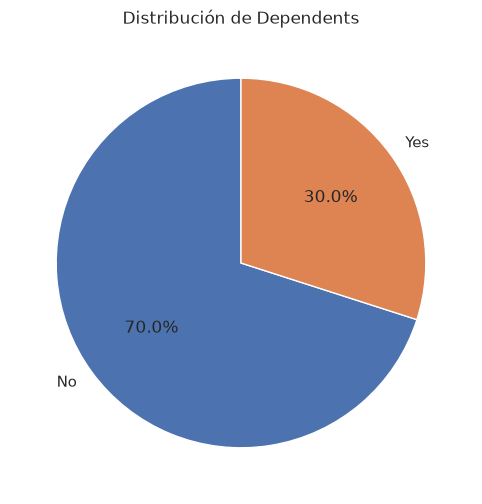

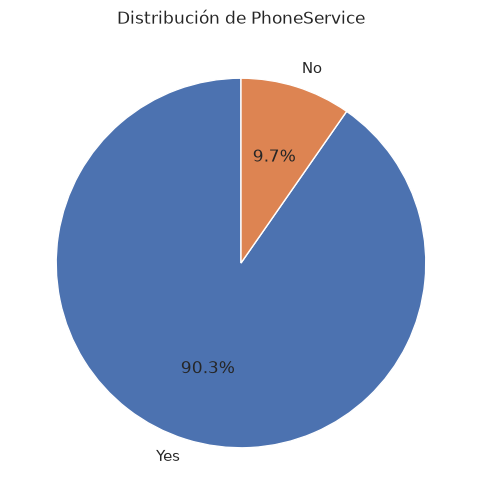

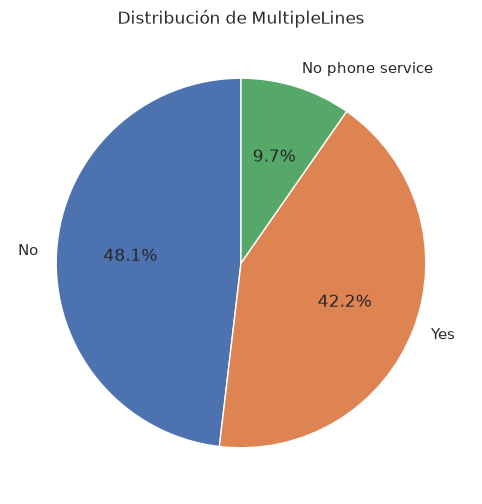

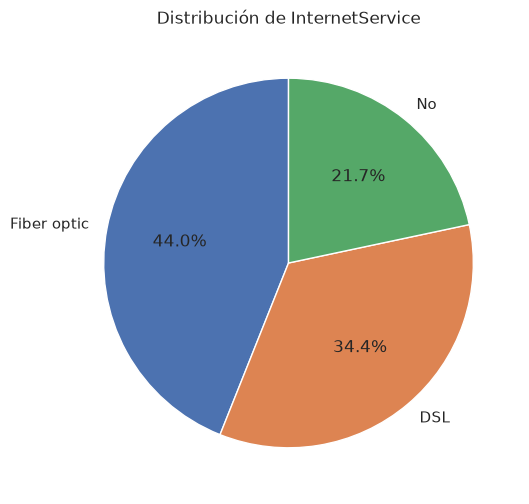

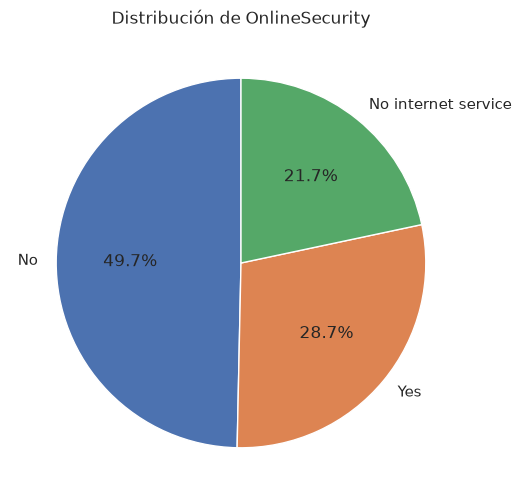

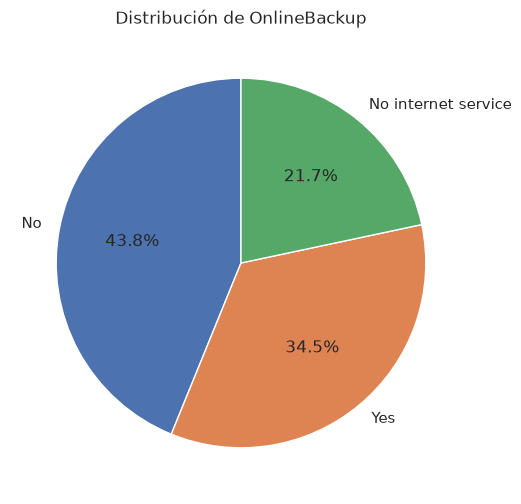

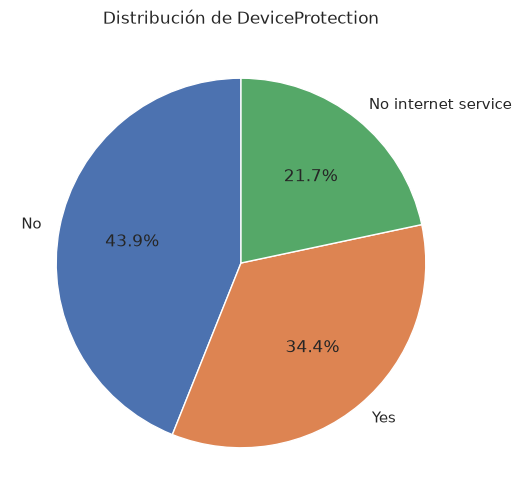

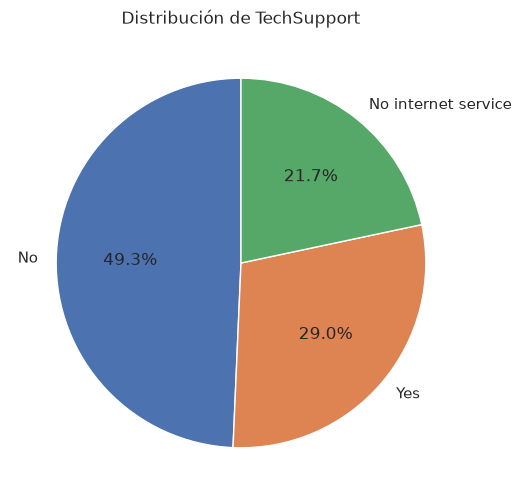

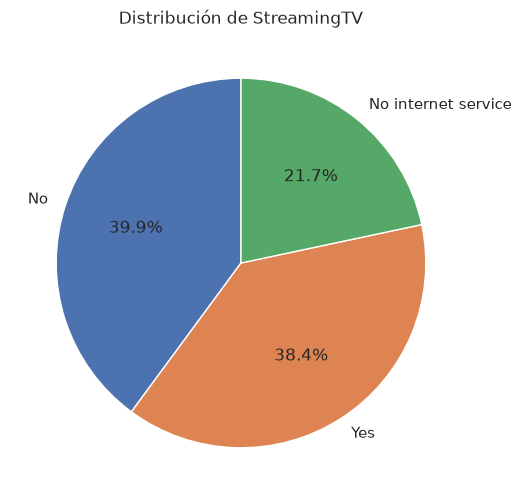

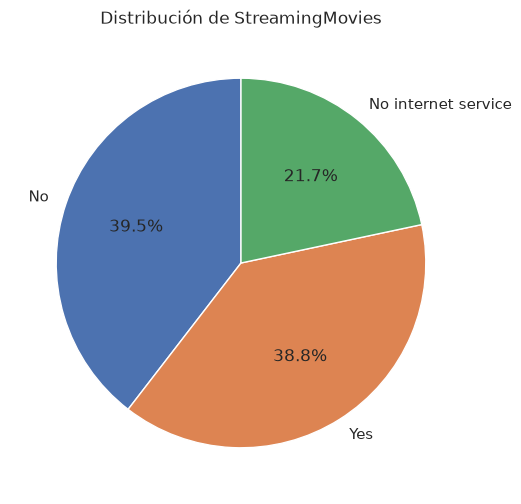

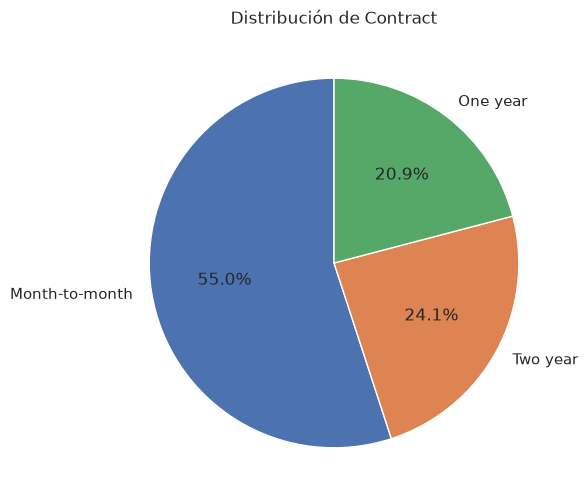

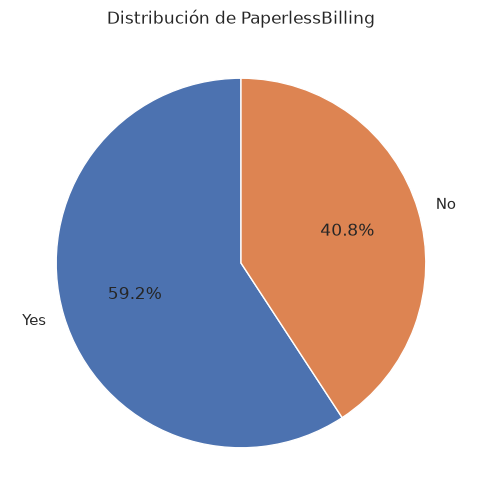

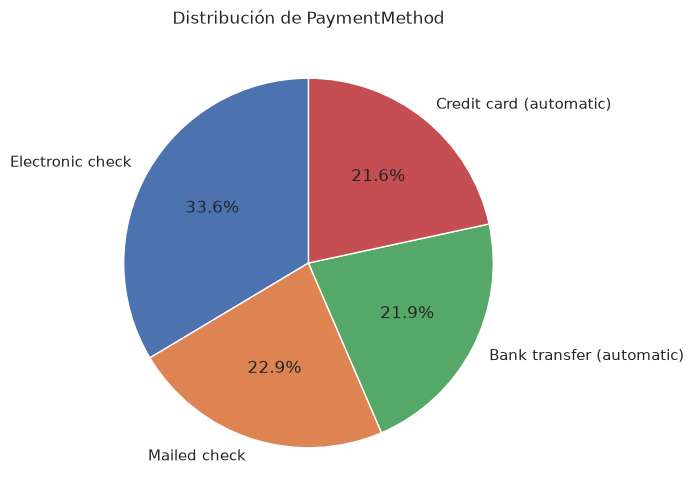

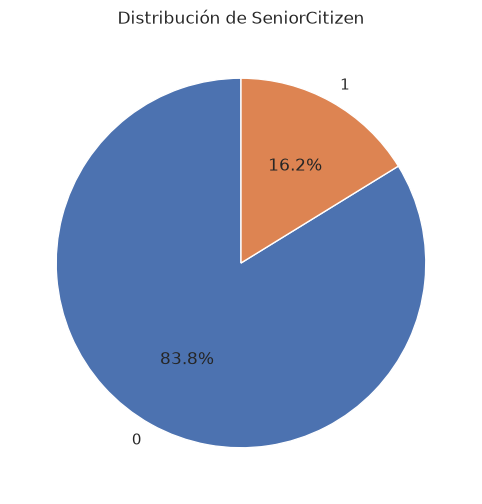

In [43]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols.append("SeniorCitizen")

for col in cat_cols:
    col_pct = df[col].value_counts(normalize=True) * 100
    plt.figure(figsize=(6, 6))
    plt.pie(
        col_pct,
        labels=col_pct.index,
        autopct="%1.1f%%",
        startangle=90
    )
    plt.title(f"Distribución de {col}")
    plt.show()